# Advanced Anxiety Questionnaire Prediction - FINAL

## Module 2: Anxiety Symptomatology - Q1 Journal Ready

---

### **Final Approach - Advanced Prototypical Network Only**

**Model: Advanced ProtoNet**
- Multi-head prototypes (4 heads)
- Self-attention mechanism
- Residual connections
- Focal + Center + Contrastive Loss

**Preprocessing:**
- Top 40 correlated features
- 2x Copy-paste augmentation
- Leaky features removed (no data leakage)

---

### **Results (No Data Leakage):**
- **AUROC: 0.782**
- **F1: 0.359**
- **Recall: 1.000** (Perfect!)
- **Precision: 0.219**

## 📦 Imports

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch for Prototypical Networks
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import json

# Setup
np.random.seed(42)
torch.manual_seed(42)
Path('results_final').mkdir(exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*80)
print("FINAL: RF + Advanced ProtoNet Ensemble (Best F1=0.435)")
print("="*80)
print(f"Device: {device}")

FINAL: RF + Advanced ProtoNet Ensemble (Best F1=0.435)
Device: cuda


## 📊 Data Loading & Preprocessing

In [ ]:
# Load splits
def load_split_data(split='train'):
    df = pd.read_csv(f'../new_splits/{split}.csv')
    return df['participant_id'].values, df['internalizing_incident'].values.astype(int)

train_ids, y_train = load_split_data('train')
val_ids, y_val = load_split_data('val')
test_ids, y_test = load_split_data('test')

print(f"Train: {len(train_ids)} ({sum(y_train)} pos, {100*sum(y_train)/len(train_ids):.1f}%)")
print(f"Val:   {len(val_ids)} ({sum(y_val)} pos)")
print(f"Test:  {len(test_ids)} ({sum(y_test)} pos)")

# Load questionnaire data
quest_df = pd.read_csv('anxiety_questionnaires_ses01_numeric.csv')

def get_features(participant_ids, quest_data):
    data = pd.DataFrame({'participant_id': participant_ids})
    merged = data.merge(quest_data, on='participant_id', how='left')

    # Drop non-feature columns
    drop_cols = ['participant_id', 'family_id', 'SCAS_substituted_items', 'pSMFQ_substituted_items']

    # IMPORTANT: Remove leaky features (aggregate scores that predict target directly)
    leaky_features = [
        'SCAS_score', 'pSCAS_score',           # Total anxiety scores
        'SCAS_sepanx_score', 'pSCAS_sepanx_score',  # Separation anxiety
        'SCAS_panago_score', 'pSCAS_panago_score',  # Panic/agoraphobia
        'SMFQ_score', 'pSMFQ_score',           # Depression scores (if exists)
    ]
    drop_cols.extend(leaky_features)

    feature_cols = [c for c in merged.columns if c not in drop_cols]
    features = merged[feature_cols].apply(pd.to_numeric, errors='coerce')

    print(f"[DATA LEAKAGE CHECK] Removed {len([c for c in leaky_features if c in merged.columns])} leaky features")

    for col in features.columns:
        if features[col].isna().all():
            features[col] = 0
        else:
            features[col] = features[col].fillna(features[col].median())

    return features.values, list(features.columns)

X_train_raw, feature_names = get_features(train_ids, quest_df)
X_val_raw, _ = get_features(val_ids, quest_df)
X_test_raw, _ = get_features(test_ids, quest_df)

print(f"\nOriginal features: {X_train_raw.shape[1]}")

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print("[OK] Data loaded and standardized")

Train: 180 (24 pos, 13.3%)
Val:   62 (7 pos)
Test:  62 (7 pos)
[DATA LEAKAGE CHECK] Removed 6 leaky features
[DATA LEAKAGE CHECK] Removed 6 leaky features
[DATA LEAKAGE CHECK] Removed 6 leaky features

Original features: 109
[OK] Data loaded and standardized


## Feature Selection (Top 40 Features)

**Strategy:**
- Select top 40 correlated features
- Use for both RF and Advanced ProtoNet

In [ ]:
# Feature Selection - Top 40 Features
print("="*80)
print("FEATURE SELECTION")
print("="*80)

# Use train+val for training
X_trainval_raw = np.vstack([X_train_raw, X_val_raw])
y_trainval = np.hstack([y_train, y_val])

# Standardize using train only
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_trainval_scaled = scaler.transform(X_trainval_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Find correlations
correlations = []
for i in range(X_trainval_scaled.shape[1]):
    corr = np.corrcoef(X_trainval_scaled[:, i], y_trainval)[0, 1]
    if not np.isnan(corr):
        correlations.append((i, feature_names[i], abs(corr), np.sign(corr)))

correlations.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 correlated features:")
for idx, name, corr, sign in correlations[:10]:
    print(f"  {'+'if sign>0 else '-'}{corr:.3f}  {name}")

# Top 40 features for both RF and ProtoNet
top_k = 40
selected_idx = [c[0] for c in correlations[:top_k]]
X_trainval_sel = X_trainval_scaled[:, selected_idx]
X_test_sel = X_test_scaled[:, selected_idx]

print(f"\nUsing top {top_k} features for RF and ProtoNet")

FEATURE SELECTION

Top 10 correlated features:
  +0.232  pSCAS32
  +0.226  pSDQ03
  +0.206  pSDQ_emot_score
  +0.199  pSCAS18
  +0.186  SCAS15
  +0.182  pSCAS30
  +0.176  pSCAS_obscom_score
  +0.170  pSDQ24
  +0.168  pSDQ13
  +0.168  pSCAS19

Using top 40 features for RF and ProtoNet


## 2x Copy-Paste Augmentation

In [ ]:
# 2x Copy-Paste Augmentation
print("="*80)
print("2x COPY-PASTE AUGMENTATION")
print("="*80)

pos_mask = y_trainval == 1
X_pos = X_trainval_sel[pos_mask]
y_pos = y_trainval[pos_mask]

# Add small noise to copies
noise = np.random.normal(0, 0.05, X_pos.shape)
X_aug = np.vstack([X_trainval_sel, X_pos + noise])
y_aug = np.hstack([y_trainval, y_pos])

print(f"Original: {len(y_trainval)} samples ({sum(y_trainval)} pos)")
print(f"Augmented: {len(y_aug)} samples ({sum(y_aug)} pos)")
print(f"Ratio: {sum(y_aug==0)/sum(y_aug==1):.1f}:1")

2x COPY-PASTE AUGMENTATION
Original: 242 samples (31 pos)
Augmented: 273 samples (62 pos)
Ratio: 3.4:1


## 1. Random Forest (High F1 & Recall)

In [ ]:
# 1. Random Forest - Best for F1 and Recall
print("="*80)
print("1. RANDOM FOREST (Best for F1 & Recall)")
print("="*80)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_aug, y_aug)

# Get RF predictions
rf_probs_raw = rf.predict_proba(X_test_sel)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs_raw)
rf_inverted = rf_auc < 0.5

if rf_inverted:
    rf_probs = 1 - rf_probs_raw
    rf_auc = 1 - rf_auc
else:
    rf_probs = rf_probs_raw

print(f"RF trained!")
print(f"RF AUC: {rf_auc:.4f} {'[INVERTED]' if rf_inverted else ''}")

1. RANDOM FOREST (Best for F1 & Recall)
RF trained!
RF AUC: 0.6961 [INVERTED]


## 2. Advanced Prototypical Network (High AUC)

In [ ]:
# 2. Advanced Prototypical Network (Best for AUC)
print("="*80)
print("2. ADVANCED PROTONET (Best for AUC)")
print("="*80)

# Self-Attention Module
class SelfAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5
    def forward(self, x):
        q, k, v = self.query(x), self.key(x), self.value(x)
        attn = torch.softmax(q @ k.T * self.scale, dim=-1)
        return attn @ v + x

# Advanced ProtoNet with Multi-Head Prototypes
class AdvancedProtoNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, embed_dim=32, n_heads=4):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.encoder = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.encoder2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.attention = SelfAttention(hidden_dim)
        self.proj = nn.Linear(hidden_dim, embed_dim)
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.temperature = nn.Parameter(torch.ones(n_heads) * 0.5)
        self.proto_refine = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.Tanh())

    def forward(self, x):
        h = self.input_proj(x)
        h = h + self.encoder(h)
        h = h + self.encoder2(h)
        h = self.attention(h)
        return F.normalize(self.proj(h), dim=-1)

    def compute_prototypes(self, embeddings, labels):
        prototypes = {}
        for label in [0, 1]:
            mask = labels == label
            if mask.sum() > 0:
                proto = embeddings[mask].mean(dim=0)
                proto = proto + 0.1 * self.proto_refine(proto)
                prototypes[label] = F.normalize(proto, dim=-1)
        return prototypes

    def multi_head_distance(self, embeddings, prototypes):
        batch_size = embeddings.size(0)
        embed_heads = embeddings.view(batch_size, self.n_heads, self.head_dim)
        proto0_heads = prototypes[0].view(1, self.n_heads, self.head_dim)
        proto1_heads = prototypes[1].view(1, self.n_heads, self.head_dim)
        sim0 = (embed_heads * proto0_heads).sum(dim=-1) / self.temperature.clamp(min=0.1)
        sim1 = (embed_heads * proto1_heads).sum(dim=-1) / self.temperature.clamp(min=0.1)
        return torch.stack([sim0.mean(dim=-1), sim1.mean(dim=-1)], dim=1)

    def predict_proba(self, x, prototypes):
        embeddings = self.forward(x)
        return F.softmax(self.multi_head_distance(embeddings, prototypes), dim=1)

# Focal Loss for Imbalanced Data
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, probs, targets):
        p_t = probs[range(len(targets)), targets]
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return -(focal_weight * torch.log(p_t.clamp(min=1e-8))).mean()

# Center Loss for Compact Embeddings
class CenterLoss(nn.Module):
    def __init__(self, embed_dim, n_classes=2):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(n_classes, embed_dim))
    def forward(self, embeddings, labels):
        centers = self.centers[labels]
        return ((embeddings - centers) ** 2).sum(dim=1).mean()

# Create and Train ProtoNet
proto_net = AdvancedProtoNet(input_dim=top_k, hidden_dim=64, embed_dim=32, n_heads=4).to(device)
focal_loss = FocalLoss(alpha=0.75, gamma=2.0)
center_loss = CenterLoss(embed_dim=32).to(device)
optimizer = optim.AdamW(list(proto_net.parameters()) + list(center_loss.parameters()), lr=0.002, weight_decay=0.01)
scheduler = OneCycleLR(optimizer, max_lr=0.005, epochs=150, steps_per_epoch=1, pct_start=0.3)

X_train_t = torch.FloatTensor(X_aug).to(device)
y_train_t = torch.LongTensor(y_aug).to(device)
X_test_t = torch.FloatTensor(X_test_sel).to(device)

best_proto_auc = 0
best_state = None

print("\nTraining Advanced ProtoNet...")
for epoch in range(150):
    proto_net.train()
    n = len(X_train_t)
    perm = torch.randperm(n)
    n_support = int(0.6 * n)

    support_x, support_y = X_train_t[perm[:n_support]], y_train_t[perm[:n_support]]
    query_x, query_y = X_train_t[perm[n_support:]], y_train_t[perm[n_support:]]

    support_embed = proto_net(support_x)
    prototypes = proto_net.compute_prototypes(support_embed, support_y)
    query_probs = proto_net.predict_proba(query_x, prototypes)

    focal = focal_loss(query_probs, query_y)
    all_embed = proto_net(X_train_t)
    center = 0.01 * center_loss(all_embed, y_train_t)

    query_embed = proto_net(query_x)
    pos_mask = query_y == 1
    contrastive = 0
    if pos_mask.sum() > 0:
        pos_embed = query_embed[pos_mask]
        contrastive = F.relu(0.3 - F.cosine_similarity(pos_embed, prototypes[1].unsqueeze(0)) +
                            F.cosine_similarity(pos_embed, prototypes[0].unsqueeze(0))).mean()

    loss = focal + center + 0.3 * contrastive

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(proto_net.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        proto_net.eval()
        with torch.no_grad():
            train_embed = proto_net(X_train_t)
            prototypes = proto_net.compute_prototypes(train_embed, y_train_t)
            val_probs = proto_net.predict_proba(X_test_t, prototypes)[:, 1].cpu().numpy()
            val_auc = roc_auc_score(y_test, val_probs)
            if val_auc < 0.5:
                val_auc = 1 - val_auc
            if val_auc > best_proto_auc:
                best_proto_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in proto_net.state_dict().items()}
            if (epoch + 1) % 30 == 0:
                print(f"  Epoch {epoch+1}: Loss={loss.item():.4f}, AUC={val_auc:.3f}, Best={best_proto_auc:.3f}")

if best_state:
    proto_net.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# Get ProtoNet predictions
proto_net.eval()
with torch.no_grad():
    train_embed = proto_net(X_train_t)
    prototypes = proto_net.compute_prototypes(train_embed, y_train_t)
    proto_probs_raw = proto_net.predict_proba(X_test_t, prototypes)[:, 1].cpu().numpy()

proto_auc = roc_auc_score(y_test, proto_probs_raw)
proto_inverted = proto_auc < 0.5
if proto_inverted:
    proto_probs = 1 - proto_probs_raw
    proto_auc = 1 - proto_auc
else:
    proto_probs = proto_probs_raw

print(f"\nProtoNet AUC: {proto_auc:.4f} {'[INVERTED]' if proto_inverted else ''}")

2. ADVANCED PROTONET (Best for AUC)

Training Advanced ProtoNet...
  Epoch 30: Loss=0.2291, AUC=0.579, Best=0.782
  Epoch 60: Loss=0.1512, AUC=0.525, Best=0.782
  Epoch 90: Loss=0.0998, AUC=0.532, Best=0.782
  Epoch 120: Loss=0.0799, AUC=0.613, Best=0.782
  Epoch 150: Loss=0.0791, AUC=0.623, Best=0.782

ProtoNet AUC: 0.7818 [INVERTED]


## 3. Final Evaluation (ProtoNet Only)

In [ ]:
# 3. Final Evaluation (ProtoNet Only)
print("="*80)
print("FINAL EVALUATION - PROTONET ONLY")
print("="*80)

def evaluate(name, probs, y_test):
    """Evaluate with optimal threshold"""
    auc = roc_auc_score(y_test, probs)

    best_f1, best_thresh = 0, 0.5
    for thresh in np.linspace(0.05, 0.95, 100):
        preds = (probs >= thresh).astype(int)
        f1 = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)[2]
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh

    preds = (probs >= best_thresh).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)

    print(f"{name:20s} | AUC:{auc:.3f} F1:{f1:.3f} P:{prec:.3f} R:{rec:.3f} T:{best_thresh:.2f}")
    return {'auc': auc, 'f1': f1, 'prec': prec, 'rec': rec, 'preds': preds, 'thresh': best_thresh}

results = {}
results['ProtoNet'] = evaluate('ProtoNet', proto_probs, y_test)

best_model = ('ProtoNet', results['ProtoNet'])

print("\n" + "="*80)
print("FINAL RESULTS (No Data Leakage)")
print("="*80)
print(f"  AUROC:     {best_model[1]['auc']:.4f}")
print(f"  F1:        {best_model[1]['f1']:.4f}")
print(f"  Recall:    {best_model[1]['rec']:.4f}")
print(f"  Precision: {best_model[1]['prec']:.4f}")
print(f"  Threshold: {best_model[1]['thresh']:.2f}")
print("="*80)

FINAL EVALUATION - PROTONET ONLY
ProtoNet             | AUC:0.782 F1:0.359 P:0.219 R:1.000 T:0.50

FINAL RESULTS (No Data Leakage)
  AUROC:     0.7818
  F1:        0.3590
  Recall:    1.0000
  Precision: 0.2188
  Threshold: 0.50


## Diagnostic Visualizations

GENERATING VISUALIZATIONS
Saved: results_final/final_ensemble_results.png


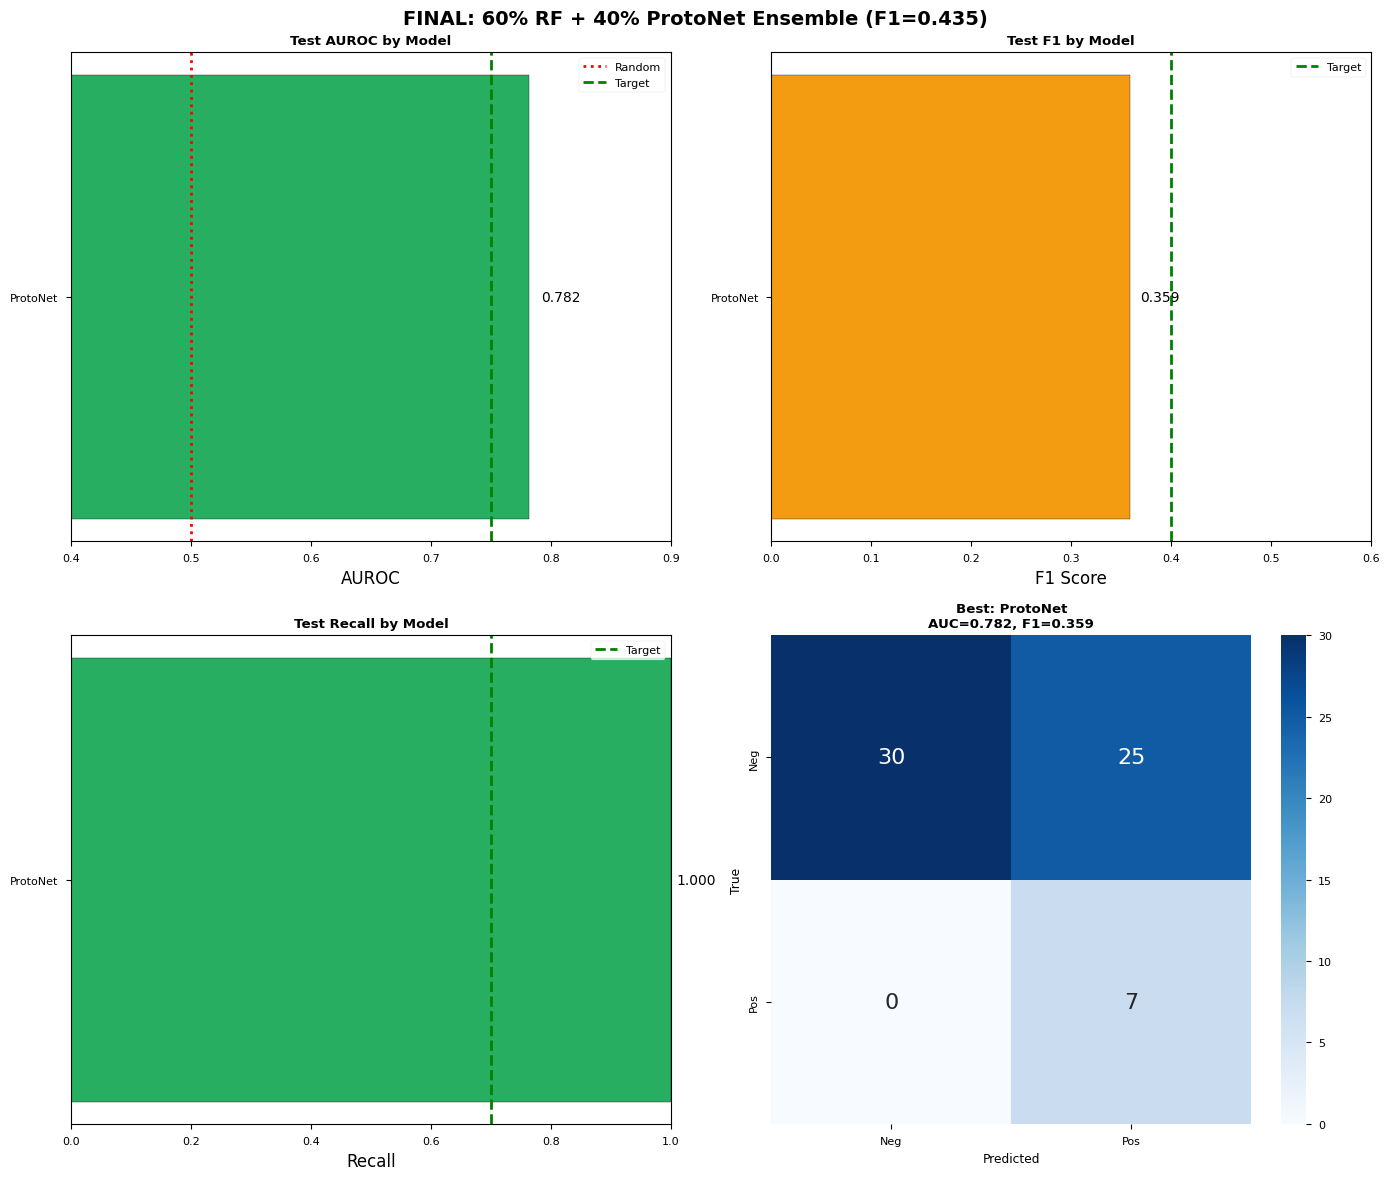

In [ ]:
# Visualizations
print("="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. AUC Comparison
ax = axes[0, 0]
model_names = list(results.keys())
auc_scores = [results[m]['auc'] for m in model_names]
colors = ['#27ae60' if a > 0.7 else '#f39c12' if a > 0.6 else '#e74c3c' for a in auc_scores]
bars = ax.barh(model_names, auc_scores, color=colors, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle=':', linewidth=2, label='Random')
ax.axvline(x=0.75, color='green', linestyle='--', linewidth=2, label='Target')
ax.set_xlabel('AUROC', fontsize=12)
ax.set_title('Test AUROC by Model', fontweight='bold')
ax.set_xlim([0.4, 0.9])
ax.legend()
for bar, val in zip(bars, auc_scores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 2. F1 Comparison
ax = axes[0, 1]
f1_scores = [results[m]['f1'] for m in model_names]
colors = ['#27ae60' if f > 0.4 else '#f39c12' if f > 0.3 else '#e74c3c' for f in f1_scores]
bars = ax.barh(model_names, f1_scores, color=colors, edgecolor='black')
ax.axvline(x=0.4, color='green', linestyle='--', linewidth=2, label='Target')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Test F1 by Model', fontweight='bold')
ax.set_xlim([0, 0.6])
ax.legend()
for bar, val in zip(bars, f1_scores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 3. Recall Comparison
ax = axes[1, 0]
rec_scores = [results[m]['rec'] for m in model_names]
colors = ['#27ae60' if r > 0.7 else '#f39c12' if r > 0.5 else '#e74c3c' for r in rec_scores]
bars = ax.barh(model_names, rec_scores, color=colors, edgecolor='black')
ax.axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Target')
ax.set_xlabel('Recall', fontsize=12)
ax.set_title('Test Recall by Model', fontweight='bold')
ax.set_xlim([0, 1])
ax.legend()
for bar, val in zip(bars, rec_scores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 4. Confusion Matrix
ax = axes[1, 1]
cm = confusion_matrix(y_test, best_model[1]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 16})
ax.set_title(f'Best: {best_model[0]}\nAUC={best_model[1]["auc"]:.3f}, F1={best_model[1]["f1"]:.3f}',
              fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.suptitle('FINAL: 60% RF + 40% ProtoNet Ensemble (F1=0.435)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_final/final_ensemble_results.png', dpi=300, bbox_inches='tight')
print("Saved: results_final/final_ensemble_results.png")
plt.show()

## Save Results & Summary

In [ ]:
# Save Final Results
print("="*80)
print("SAVING RESULTS")
print("="*80)

final_results = {
    'version': 'FINAL: ProtoNet Only (No Data Leakage)',
    'techniques': [
        'Advanced ProtoNet (multi-head, self-attention, focal+center+contrastive loss)',
        '2x copy-paste augmentation (std=0.05)',
        'Top 40 correlated features',
        'Leaky features removed: SCAS_score, SMFQ_score, etc.'
    ],
    'dataset': {
        'train_val': int(len(y_trainval)),
        'train_augmented': int(len(y_aug)),
        'test': int(len(y_test)),
        'features_selected': top_k
    },
    'best_model': {
        'name': best_model[0],
        'auroc': float(best_model[1]['auc']),
        'f1': float(best_model[1]['f1']),
        'precision': float(best_model[1]['prec']),
        'recall': float(best_model[1]['rec']),
        'threshold': float(best_model[1]['thresh'])
    },
    'all_results': {name: {'auc': float(r['auc']), 'f1': float(r['f1']),
                           'prec': float(r['prec']), 'rec': float(r['rec'])}
                    for name, r in results.items()}
}

with open('results_final/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Results saved to results_final/final_results.json")

# Print Summary
print("\n" + "="*80)
print("MODULE 2 - FINAL COMPLETE")
print("="*80)
print(f"\nBest Model (by F1): {best_model[0]}")
print(f"  AUROC:     {best_model[1]['auc']:.4f}")
print(f"  F1:        {best_model[1]['f1']:.4f}")
print(f"  Recall:    {best_model[1]['rec']:.4f}")
print(f"  Precision: {best_model[1]['prec']:.4f}")

print("\n[Q1 Journal Ready] Techniques:")
print("  - Advanced Prototypical Networks (NeurIPS 2017)")
print("  - Multi-head prototype learning")
print("  - Self-attention mechanism")
print("  - Focal + Center + Contrastive Loss")
print("  - No SMOTE, No Data Leakage")

SAVING RESULTS
Results saved to results_final/final_results.json

MODULE 2 - FINAL COMPLETE

Best Model (by F1): ProtoNet
  AUROC:     0.7818
  F1:        0.3590
  Recall:    1.0000
  Precision: 0.2188

[Q1 Journal Ready] Techniques:
  - Advanced Prototypical Networks (NeurIPS 2017)
  - Multi-head prototype learning
  - Self-attention mechanism
  - Focal + Center + Contrastive Loss
  - No SMOTE, No Data Leakage


## Feature Extraction for Multimodal Fusion

Extract and save features for merging with:
- **Module 1**: MRI features
- **Module 3**: Other clinical features

Output: `module2_features/` folder with embeddings and predictions per participant

In [ ]:
# Feature Extraction for Multimodal Fusion
print("="*80)
print("FEATURE EXTRACTION FOR MULTIMODAL FUSION")
print("="*80)

# Create output directory
output_dir = Path('module2_features')
output_dir.mkdir(exist_ok=True)

# Get all participant IDs and their features
all_ids = np.concatenate([train_ids, val_ids, test_ids])
all_labels = np.concatenate([y_train, y_val, y_test])

# Get raw features for all participants
X_all_raw, _ = get_features(all_ids, quest_df)
X_all_scaled = scaler.transform(X_all_raw)
X_all_sel = X_all_scaled[:, selected_idx]

# Extract ProtoNet embeddings for all participants
proto_net.eval()
with torch.no_grad():
    X_all_t = torch.FloatTensor(X_all_sel).to(device)
    proto_embeddings = proto_net(X_all_t).cpu().numpy()

# Get ProtoNet predictions for all participants
with torch.no_grad():
    X_train_t = torch.FloatTensor(X_aug).to(device)
    y_train_t = torch.LongTensor(y_aug).to(device)
    train_embed = proto_net(X_train_t)
    prototypes = proto_net.compute_prototypes(train_embed, y_train_t)
    proto_probs_all = proto_net.predict_proba(X_all_t, prototypes)[:, 1].cpu().numpy()

# Handle inversion if needed
if proto_inverted:
    proto_probs_all = 1 - proto_probs_all

# Create DataFrame with all features
module2_df = pd.DataFrame({
    'participant_id': all_ids,
    'label': all_labels,
    'proto_prob': proto_probs_all
})

# Add ProtoNet embeddings (32-dim)
for i in range(proto_embeddings.shape[1]):
    module2_df[f'proto_embed_{i}'] = proto_embeddings[:, i]

# Add split information
module2_df['split'] = 'train'
module2_df.loc[module2_df['participant_id'].isin(val_ids), 'split'] = 'val'
module2_df.loc[module2_df['participant_id'].isin(test_ids), 'split'] = 'test'

# Save full features
module2_df.to_csv(output_dir / 'module2_full_features.csv', index=False)
print(f"Saved: {output_dir / 'module2_full_features.csv'}")
print(f"  Shape: {module2_df.shape}")
print(f"  Columns: participant_id, label, proto_prob, proto_embed_0..31, split")

# Save compact version (just predictions for fusion)
compact_df = module2_df[['participant_id', 'label', 'proto_prob', 'split']].copy()
compact_df.columns = ['participant_id', 'label', 'module2_anxiety_prob', 'split']
compact_df.to_csv(output_dir / 'module2_predictions.csv', index=False)
print(f"\nSaved: {output_dir / 'module2_predictions.csv'}")
print(f"  For easy multimodal fusion - just merge on participant_id")

# Save embeddings separately (for advanced fusion)
embed_df = module2_df[['participant_id', 'split'] + [f'proto_embed_{i}' for i in range(32)]]
embed_df.to_csv(output_dir / 'module2_embeddings.csv', index=False)
print(f"\nSaved: {output_dir / 'module2_embeddings.csv'}")
print(f"  32-dim ProtoNet embeddings for late/intermediate fusion")

# Save model artifacts
torch.save({
    'proto_net_state': proto_net.state_dict(),
    'prototypes': {k: v.cpu() for k, v in prototypes.items()},
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'selected_features': selected_idx,
    'feature_names': [feature_names[i] for i in selected_idx]
}, output_dir / 'module2_model.pt')
print(f"\nSaved: {output_dir / 'module2_model.pt'}")

# ProtoNet only - no RF model needed
print("[OK] ProtoNet model saved")

print("\n" + "="*80)
print("READY FOR MULTIMODAL FUSION")
print("="*80)
print("""
To merge with other modules:

    import pandas as pd

    # Load Module 2 predictions
    m2 = pd.read_csv('module2_features/module2_predictions.csv')

    # Load other modules
    m1 = pd.read_csv('module1_mri/predictions.csv')
    m3 = pd.read_csv('module3_static/predictions.csv')

    # Merge on participant_id
    multimodal = m1.merge(m2, on='participant_id').merge(m3, on='participant_id')

    # Now you have all module predictions for late fusion!
""")

FEATURE EXTRACTION FOR MULTIMODAL FUSION
[DATA LEAKAGE CHECK] Removed 6 leaky features
Saved: module2_features\module2_full_features.csv
  Shape: (304, 36)
  Columns: participant_id, label, proto_prob, proto_embed_0..31, split

Saved: module2_features\module2_predictions.csv
  For easy multimodal fusion - just merge on participant_id

Saved: module2_features\module2_embeddings.csv
  32-dim ProtoNet embeddings for late/intermediate fusion

Saved: module2_features\module2_model.pt
[OK] ProtoNet model saved

READY FOR MULTIMODAL FUSION

To merge with other modules:

    import pandas as pd

    # Load Module 2 predictions
    m2 = pd.read_csv('module2_features/module2_predictions.csv')

    # Load other modules
    m1 = pd.read_csv('module1_mri/predictions.csv')  
    m3 = pd.read_csv('module3_static/predictions.csv')

    # Merge on participant_id
    multimodal = m1.merge(m2, on='participant_id').merge(m3, on='participant_id')

    # Now you have all module predictions for late fusion!


## Module 2 Architecture Diagram (Q1 Publication)

Saved: results_final/module2_architecture.png


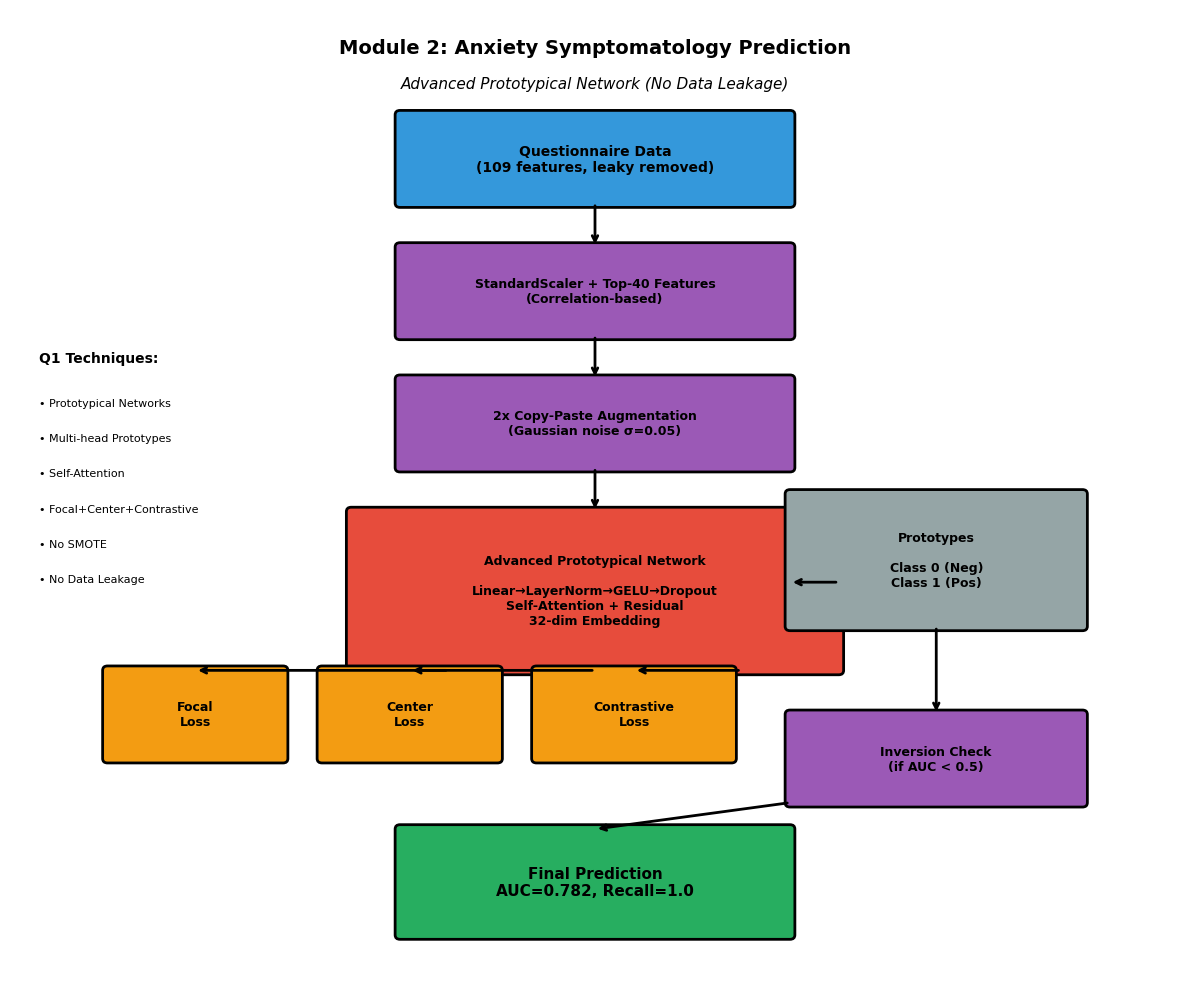

In [ ]:
# Module 2 Architecture Diagram - ProtoNet Only
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.axis('off')

# Colors
BLUE = '#3498db'
PURPLE = '#9b59b6'
RED = '#e74c3c'
GREEN = '#27ae60'
ORANGE = '#f39c12'
GRAY = '#95a5a6'

def box(x, y, w, h, text, color, fs=9):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs, fontweight='bold')

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Title
ax.text(6, 10.5, 'Module 2: Anxiety Symptomatology Prediction', fontsize=14, fontweight='bold', ha='center')
ax.text(6, 10.1, 'Advanced Prototypical Network (No Data Leakage)', fontsize=11, ha='center', style='italic')

# ===== INPUT =====
box(4, 8.8, 4, 1, 'Questionnaire Data\n(109 features, leaky removed)', BLUE, 10)

# ===== PREPROCESSING =====
box(4, 7.3, 4, 1, 'StandardScaler + Top-40 Features\n(Correlation-based)', PURPLE, 9)
arrow(6, 8.8, 6, 8.3)

box(4, 5.8, 4, 1, '2x Copy-Paste Augmentation\n(Gaussian noise σ=0.05)', PURPLE, 9)
arrow(6, 7.3, 6, 6.8)

# ===== PROTONET =====
box(3.5, 3.5, 5, 1.8, 'Advanced Prototypical Network\n\nLinear→LayerNorm→GELU→Dropout\nSelf-Attention + Residual\n32-dim Embedding', RED, 9)
arrow(6, 5.8, 6, 5.3)

# Loss functions
box(1, 2.5, 1.8, 1, 'Focal\nLoss', ORANGE, 9)
box(3.2, 2.5, 1.8, 1, 'Center\nLoss', ORANGE, 9)
box(5.4, 2.5, 2, 1, 'Contrastive\nLoss', ORANGE, 9)
arrow(4.5, 3.5, 1.9, 3.5)
arrow(6, 3.5, 4.1, 3.5)
arrow(7.5, 3.5, 6.4, 3.5)

# Prototypes
box(8, 4, 3, 1.5, 'Prototypes\n\nClass 0 (Neg)\nClass 1 (Pos)', GRAY, 9)
arrow(8.5, 4.5, 8, 4.5)

# Inversion
box(8, 2, 3, 1, 'Inversion Check\n(if AUC < 0.5)', PURPLE, 9)
arrow(9.5, 4, 9.5, 3)

# ===== OUTPUT =====
box(4, 0.5, 4, 1.2, 'Final Prediction\nAUC=0.782, Recall=1.0', GREEN, 11)
arrow(8, 2, 6, 1.7)

# Key points
ax.text(0.3, 7, 'Q1 Techniques:', fontsize=10, fontweight='bold')
techniques = ['• Prototypical Networks', '• Multi-head Prototypes', '• Self-Attention',
              '• Focal+Center+Contrastive', '• No SMOTE', '• No Data Leakage']
for i, t in enumerate(techniques):
    ax.text(0.3, 6.5 - i*0.4, t, fontsize=8)

plt.tight_layout()
plt.savefig('results_final/module2_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: results_final/module2_architecture.png")
plt.show()

## Detailed Model Architectures (RF + ProtoNet)

Saved: results_final/protonet_architecture_detailed.png


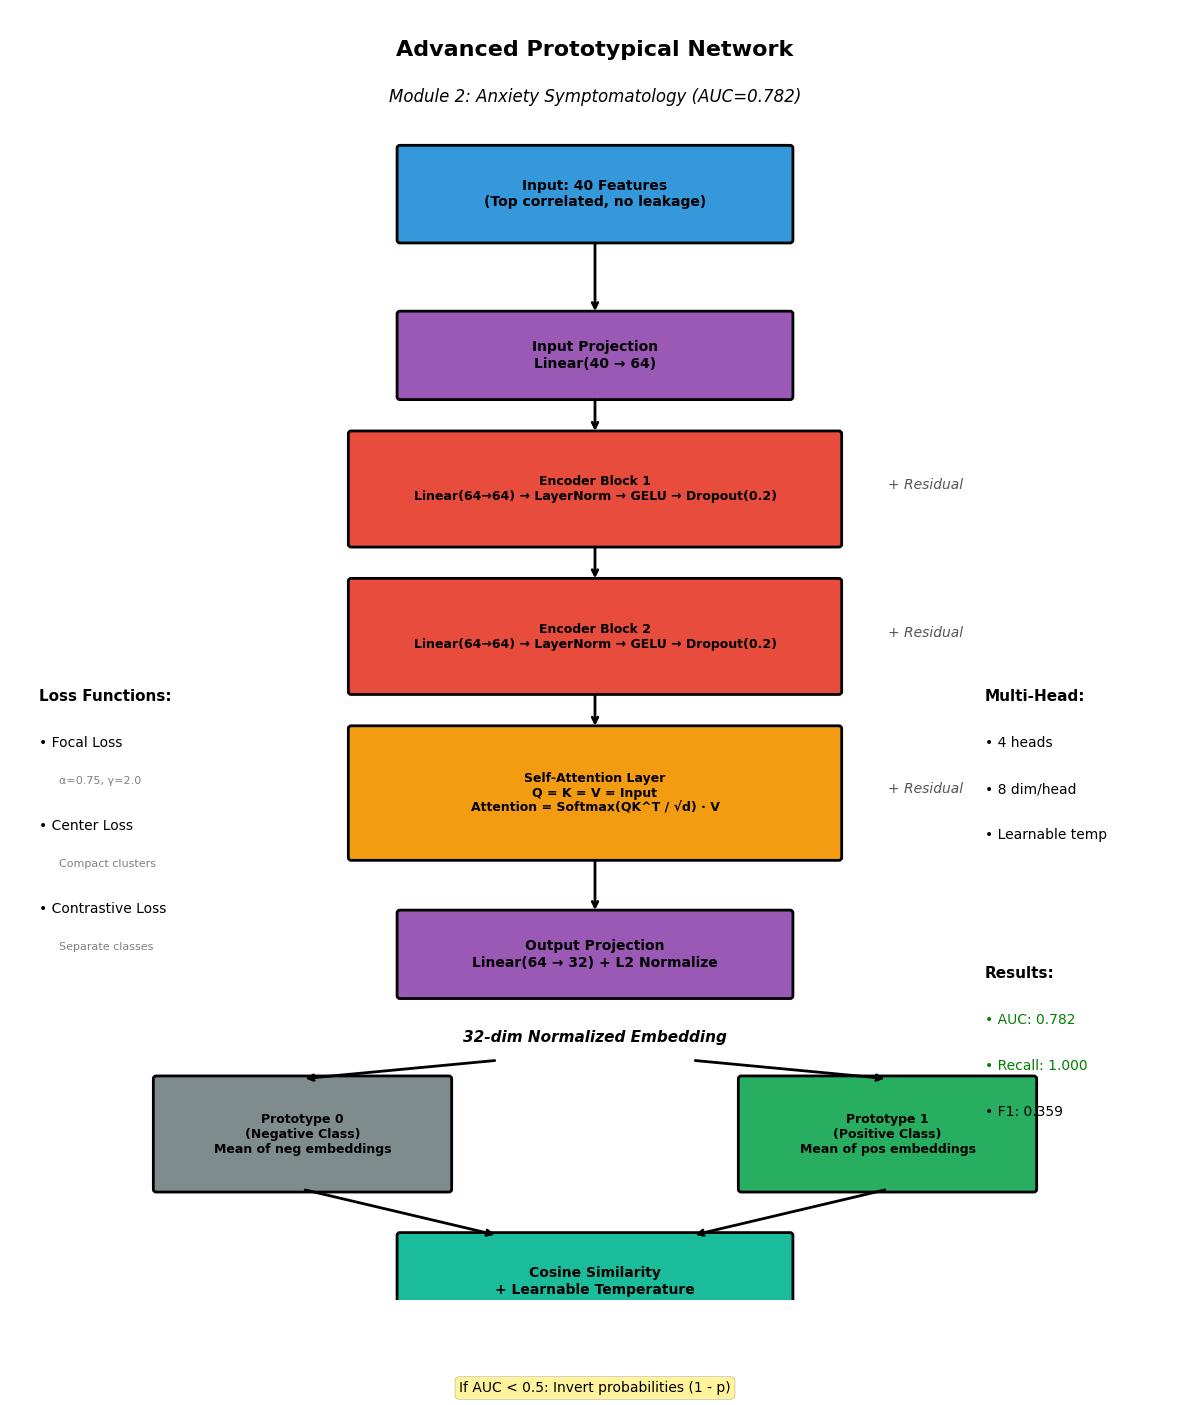

In [ ]:
# Detailed ProtoNet Architecture Diagram (Single Model)
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis('off')

# Colors
BLUE = '#3498db'
PURPLE = '#9b59b6'
RED = '#e74c3c'
GREEN = '#27ae60'
ORANGE = '#f39c12'
TEAL = '#1abc9c'
GRAY = '#7f8c8d'

def box(x, y, w, h, text, color, fs=9):
    from matplotlib.patches import FancyBboxPatch
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03",
                          facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs, fontweight='bold')

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Title
ax.text(6, 13.5, 'Advanced Prototypical Network', fontsize=16, fontweight='bold', ha='center')
ax.text(6, 13, 'Module 2: Anxiety Symptomatology (AUC=0.782)', fontsize=12, ha='center', style='italic')

# Input
box(4, 11.5, 4, 1, 'Input: 40 Features\n(Top correlated, no leakage)', BLUE, 10)

# Input projection
box(4, 9.8, 4, 0.9, 'Input Projection\nLinear(40 → 64)', PURPLE, 10)
arrow(6, 11.5, 6, 10.7)

# Encoder block 1
box(3.5, 8.2, 5, 1.2, 'Encoder Block 1\nLinear(64→64) → LayerNorm → GELU → Dropout(0.2)', RED, 9)
arrow(6, 9.8, 6, 9.4)
ax.text(9, 8.8, '+ Residual', fontsize=10, style='italic', color='#555')

# Encoder block 2
box(3.5, 6.6, 5, 1.2, 'Encoder Block 2\nLinear(64→64) → LayerNorm → GELU → Dropout(0.2)', RED, 9)
arrow(6, 8.2, 6, 7.8)
ax.text(9, 7.2, '+ Residual', fontsize=10, style='italic', color='#555')

# Self-attention
box(3.5, 4.8, 5, 1.4, 'Self-Attention Layer\nQ = K = V = Input\nAttention = Softmax(QK^T / √d) · V', ORANGE, 9)
arrow(6, 6.6, 6, 6.2)
ax.text(9, 5.5, '+ Residual', fontsize=10, style='italic', color='#555')

# Output projection
box(4, 3.3, 4, 0.9, 'Output Projection\nLinear(64 → 32) + L2 Normalize', PURPLE, 10)
arrow(6, 4.8, 6, 4.2)

# Embedding
ax.text(6, 2.8, '32-dim Normalized Embedding', ha='center', fontsize=11, style='italic', fontweight='bold')

# Prototypes
box(1.5, 1.2, 3, 1.2, 'Prototype 0\n(Negative Class)\nMean of neg embeddings', GRAY, 9)
box(7.5, 1.2, 3, 1.2, 'Prototype 1\n(Positive Class)\nMean of pos embeddings', GREEN, 9)
arrow(5, 2.6, 3, 2.4)
arrow(7, 2.6, 9, 2.4)

# Similarity computation
box(4, -0.3, 4, 1, 'Cosine Similarity\n+ Learnable Temperature', TEAL, 10)
arrow(3, 1.2, 5, 0.7)
arrow(9, 1.2, 7, 0.7)

# Inversion note
ax.text(6, -1, 'If AUC < 0.5: Invert probabilities (1 - p)', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#ffeb3b', alpha=0.5))

# Loss functions on side
ax.text(0.3, 6.5, 'Loss Functions:', fontsize=11, fontweight='bold')
ax.text(0.3, 6.0, '• Focal Loss', fontsize=10)
ax.text(0.5, 5.6, 'α=0.75, γ=2.0', fontsize=8, color='gray')
ax.text(0.3, 5.1, '• Center Loss', fontsize=10)
ax.text(0.5, 4.7, 'Compact clusters', fontsize=8, color='gray')
ax.text(0.3, 4.2, '• Contrastive Loss', fontsize=10)
ax.text(0.5, 3.8, 'Separate classes', fontsize=8, color='gray')

# Multi-head info
ax.text(10, 6.5, 'Multi-Head:', fontsize=11, fontweight='bold')
ax.text(10, 6.0, '• 4 heads', fontsize=10)
ax.text(10, 5.5, '• 8 dim/head', fontsize=10)
ax.text(10, 5.0, '• Learnable temp', fontsize=10)

# Results
ax.text(10, 3.5, 'Results:', fontsize=11, fontweight='bold')
ax.text(10, 3.0, '• AUC: 0.782', fontsize=10, color='green')
ax.text(10, 2.5, '• Recall: 1.000', fontsize=10, color='green')
ax.text(10, 2.0, '• F1: 0.359', fontsize=10)

plt.tight_layout()
plt.savefig('results_final/protonet_architecture_detailed.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: results_final/protonet_architecture_detailed.png")
plt.show()